#โค้ด 3.1 การทำนายความน่าจะเป็นในการซื้อของหรือไม่ซื้อของ

1️⃣ เตรียมข้อมูล
เราจะ
แปลงเพศ → ตัวเลข
แยก X (features) และ y (label)

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [ ]:
# สร้าง DataFrame
data = {
    "Age": [25, 32, 41, 22, 35, 28, 38],
    "Income": [18000, 45000, 70000, 15000, 50000, 20000, 65000],
    "Gender": ["หญิง", "ชาย", "หญิง", "ชาย", "หญิง", "ชาย", "หญิง"],
    "Visits_per_week": [5, 8, 4, 3, 7, 6, 9],
    "Avg_time": [8, 15, 6, 4, 12, 5, 14],
    "Buy": [0, 1, 1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)


2️⃣ แปลงข้อมูลเชิงหมวด (เพศ)
Logistic Regression ใช้ตัวเลข → แปลงเพศเป็น 0/1

In [ ]:
df["Gender"] = df["Gender"].map({"ชาย": 1, "หญิง": 0})


3️⃣ แยก Feature และ Label

In [ ]:
X = df.drop("Buy", axis=1)
y = df["Buy"]


4️⃣ สร้างโมเดล Logistic Regression
เราใช้ Pipeline เพื่อ
ปรับสเกลข้อมูล
เทรนโมเดลในขั้นตอนเดียว

In [ ]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression())
])

model.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic', LogisticRegression())])

5️⃣ ทำนาย “ความน่าจะเป็นในการซื้อ”
predict_proba จะให้ผลลัพธ์
[P(ไม่ซื้อ), P(ซื้อ)]

In [ ]:
probabilities = model.predict_proba(X)

df["Prob_Not_Buy"] = probabilities[:, 0]
df["Prob_Buy"] = probabilities[:, 1]

df


,Age,Income,Gender,Visits_per_week,Avg_time,Buy,Prob_Not_Buy,Prob_Buy
0,25,18000,0,5,8,0,0.783834,0.216166
1,32,45000,1,8,15,1,0.163533,0.836467
2,41,70000,0,4,6,1,0.126926,0.873074
3,22,15000,1,3,4,0,0.949457,0.050543
4,35,50000,0,7,12,1,0.133046,0.866954
5,28,20000,1,6,5,0,0.809901,0.190099
6,38,65000,0,9,14,1,0.033288,0.966712


6️⃣ ตัวอย่างการทำนายลูกค้าใหม่


In [ ]:
new_customer = pd.DataFrame({
    "Age": [30],
    "Income": [40000],
    "Gender": [1],  # ชาย
    "Visits_per_week": [7],
    "Avg_time": [10]
})

prob = model.predict_proba(new_customer)

print("ความน่าจะเป็นไม่ซื้อ:", prob[0][0])
print("ความน่าจะเป็นซื้อ:", prob[0][1])


ความน่าจะเป็นไม่ซื้อ: 0.4091327262491037
ความน่าจะเป็นซื้อ: 0.5908672737508963


การแปลผล
ค่าออกมาเช่น 0.78 มีโอกาส 78% ที่จะซื้อ
ธุรกิจอาจตั้ง threshold เช่น
* ≥ 0.7 → ส่งโปรโมชัน
* < 0.7 → แนะนำสินค้าเบา ๆ



#โค้ด 3.2 จัดกลุ่มลูกค้า


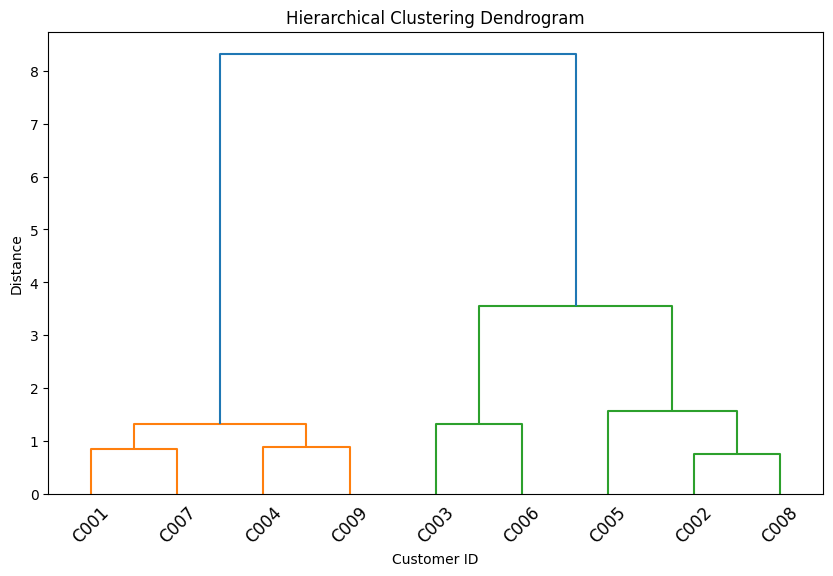

,Age,Income,Visits_per_week,Avg_time,Avg_spending
Cluster,,,,,
1,25.25,21500.000000,8.500000,4.500000,1675.000000
2,33.00,47500.000000,5.000000,11.000000,5500.000000
3,45.00,68333.333333,2.666667,15.666667,8733.333333


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

data = {
    "Customer_ID": ["C001","C002","C003","C004","C005","C006","C007","C008","C009"],
    "Age": [22,45,31,29,50,35,23,40,27],
    "Income": [15000,60000,40000,25000,75000,55000,18000,70000,28000],
    "Visits_per_week": [8,3,6,9,2,4,10,3,7],
    "Avg_time": [5,15,10,4,18,12,3,14,6],
    "Avg_spending": [1200,8000,4500,2000,10000,6500,1000,8200,2500]
}

df = pd.DataFrame(data)
df

X = df.drop("Customer_ID", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Z = linkage(X_scaled, method="ward")
# ward เหมาะกับข้อมูลเชิงตัวเลข
# ลด variance ภายในกลุ่ม

plt.figure(figsize=(10, 6))
dendrogram(
    Z,
    labels=df["Customer_ID"].values,
    leaf_rotation=45
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer ID")
plt.ylabel("Distance")
plt.show()

df["Cluster"] = fcluster(Z, t=3, criterion="maxclust")
df

df.groupby("Cluster").mean(numeric_only=True)

# การอ่านกราฟ
ต้องรันโปรแกรมข้างบนให้ได้ภาพก่อน
เส้นยิ่ง เชื่อมกันต่ำ → ยิ่ง คล้ายกันมาก
เส้นยิ่ง เชื่อมกันสูง → ยิ่ง ต่างกันมาก
## Cluster 2 กลุ่มจะตัดที่ Distance = 4 จะได้กลุ่ม


*   c001,c007,c004, c009
*   c003,c006,c005,c002,c008
## Cluster 3 กลุ่มจะตัดที่ Distance = 2 จะได้กลุ่ม
*   c001,c007,c004, c009
*   c003,c006
*   c005,c002,c008



## โค้ดแสดงกราฟในรูปแบบที่เข้าใจง่ายขึ้น ใช้เงินเดือนเป็นตัวพลอต

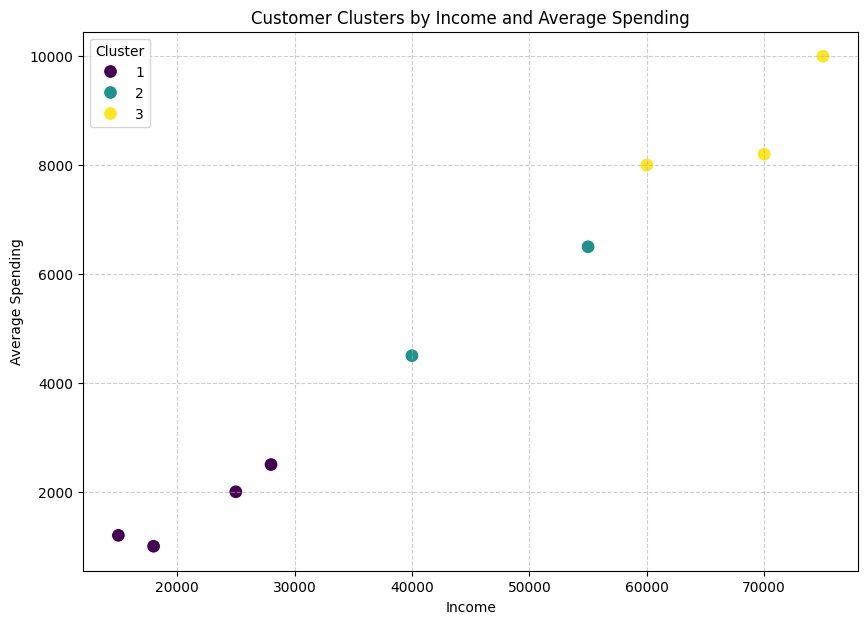

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Income', y='Avg_spending', hue='Cluster', palette='viridis', s=100)
plt.title('Customer Clusters by Income and Average Spending')
plt.xlabel('Income')
plt.ylabel('Average Spending')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()

# โค้ด 3.3 ระบบแนะนำสินค้าโดยการเรียนรู้แบบเสริมแรง
ในโค้ดนี้ระบบจะแสดง Action ของ Agent ที่จะเลือกสินค้าเพื่อนำไปแนะนำ แต่ในโค้ดถัดไปมีส่วนของ response จากผู้ใช้ ซึ่งสอดคล้องกับสถานการณ์จริงที่ Agent จะเลือกทำเมื่อได้ Response จากผู้ใช้

In [ ]:
#1️⃣ กำหนด Action และ Reward
import random
import numpy as np
# Actions
actions = [
    "recommend_running_shoes",
    "recommend_sports_clothes",
    "recommend_irrelevant_product",
    "recommend_duplicate_product"
]

# Reward mapping
reward_table = {
    "recommend_running_shoes": 0.5,
    "recommend_sports_clothes": 1.0,
    "recommend_irrelevant_product": 0.0,
    "recommend_duplicate_product": -1.0
}
# 2️⃣ สร้าง Q-Table
#ในตัวอย่างนี้
#มี state เดียว (simplified recommendation environment)
#Q-Table = ค่า Q ของแต่ละ action
Q = {action: 0.0 for action in actions}
#3️⃣ กำหนด Hyperparameters
alpha = 0.1     # learning rate
gamma = 0.9     # discount factor
epsilon = 0.2   # exploration rate
#4️⃣ ฟังก์ชันเลือก Action (ε-greedy)
def choose_action():
    if random.uniform(0, 1) < epsilon:
        return random.choice(actions)  # explore
    else:
        return max(Q, key=Q.get)        # exploit
#5️⃣ วงจรการเรียนรู้ (Training Loop)
episodes = 100

for episode in range(episodes):
    action = choose_action()
    reward = reward_table[action]

    # Q-learning update
    Q[action] = Q[action] + alpha * (
        reward + gamma * max(Q.values()) - Q[action]
    )
#6️⃣ ดูผลลัพธ์ Q-Table หลังเรียนรู้
for action, value in Q.items():
    print(f"{action}: {value:.3f}")
#7️⃣ Policy ที่ได้จากโมเดล
best_action = max(Q, key=Q.get)
print("แนะนำสินค้าที่ควรเลือก:", best_action)


recommend_running_shoes: 2.893
recommend_sports_clothes: 0.163
recommend_irrelevant_product: 0.896
recommend_duplicate_product: 0.150
แนะนำสินค้าที่ควรเลือก: recommend_running_shoes


# โค้ด 3.3 ปรับให้มีการตอบสนองจากผู้ซื้อของ โดยใช้ข้อมูลจำลอง  ระบบจะตัดสินใจว่า Agent ควรแนะนำอย่างไรในสถานการณ์ล่าสุด  (แต่ยังไม่ใช่การตอบสนองต่อผู้ใช้ที่กำลังเลือกซื้อของ)

In [ ]:
import random

actions = [
    "recommend_running_shoes",
    "recommend_sports_clothes",
    "recommend_irrelevant_product",
    "recommend_duplicate_product"
]

# reward ตาม "ผลตอบสนอง" (ไม่ใช่ตาม action ตรงๆ)
reward_by_response = {
    "click": 0.5,
    "buy": 1.0,
    "ignore": 0.0,
    "hide": -1.0
}

# จำลองความน่าจะเป็นของพฤติกรรมผู้ใช้เมื่อเจอแต่ละ action (ตัวอย่าง) ข้อมูลนี้ควรมาจากล็อกจากการทำงานจริง
# ตัวอย่างเช่น ระบบแนะนำให้ซื้อรองเท่า จะมีคนคลิกดู 60% มีซื้อจริง 10% ไม่สนใจ 25% และซ่อน 5%
response_prob = {
    "recommend_running_shoes": {"click": 0.6, "buy": 0.1, "ignore": 0.25, "hide": 0.05},
    "recommend_sports_clothes": {"click": 0.4, "buy": 0.25, "ignore": 0.3, "hide": 0.05},
    "recommend_irrelevant_product": {"click": 0.05, "buy": 0.01, "ignore": 0.8, "hide": 0.14},
    "recommend_duplicate_product": {"click": 0.02, "buy": 0.0, "ignore": 0.28, "hide": 0.70},
}

# Q-values (state เดียวเพื่อให้เข้าใจง่าย)
Q = {a: 0.0 for a in actions}

alpha = 0.1
gamma = 0.9
epsilon = 0.2

def choose_action():
    # Agent เลือก action (สุ่ม = exploration, เลือกที่ดีที่สุด = exploitation)
    if random.random() < epsilon:
        return random.choice(actions)
    return max(Q, key=Q.get)

def sample_user_response(action):
    # Environment (ผู้ใช้) ตอบสนองตามโอกาสของแต่ละ action
    outcomes = list(response_prob[action].keys())
    probs = list(response_prob[action].values())
    return random.choices(outcomes, weights=probs, k=1)[0]

episodes = 200

for _ in range(episodes):
    action = choose_action()                 # ✅ action ของ Agent
    user_response = sample_user_response(action)  # ✅ response ของผู้ใช้ (environment)
    reward = reward_by_response[user_response]    # ✅ reward จาก response

    # Q-learning update
    Q[action] = Q[action] + alpha * (reward + gamma * max(Q.values()) - Q[action])

print("Q-values:", Q)
print("Best action:", max(Q, key=Q.get))


Q-values: {'recommend_running_shoes': 1.219539781504159, 'recommend_sports_clothes': 3.397514406934896, 'recommend_irrelevant_product': 1.5621922253108371, 'recommend_duplicate_product': 0.735304992122489}
Best action: recommend_sports_clothes


# โค้ด 3.4 การตรวจจับวัตถุ คน รถยนต์ ป้ายจราจร
โมเดล: Faster R-CNN ResNet50 FPN
Dataset: COCO (pretrained)
ตรวจจับคลาส:
person
car
traffic light / stop sign (แทนป้ายจราจร)
* COCO อาจไม่สามารถหา Stop-sign เจอเพราะไม่มีการเทรนป้ายจราจร

In [ ]:
import torch
import torchvision
import cv2
import numpy as np
from torchvision import transforms
from google.colab.patches import cv2_imshow # Import cv2_imshow

#2️⃣ โหลดโมเดล Faster R-CNN (pretrained)
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()
#โมเดลนี้เรียนรู้จาก ข้อมูลภาพที่มีป้ายกำกับ (Supervised Learning)
#3️⃣ กำหนดชื่อคลาส (COCO)
COCO_CLASSES = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light", "fire hydrant",
    "stop sign"
]

#4️⃣ โหลดและแปลงภาพ
def load_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    transform = transforms.ToTensor()
    return image, transform(image)
#5️⃣ ฟังก์ชันตรวจจับวัตถุ
def detect_objects(image_path, threshold=0.6):
    image, img_tensor = load_image(image_path)

    with torch.no_grad():
        predictions = model([img_tensor])[0]

    boxes = predictions["boxes"].numpy()
    labels = predictions["labels"].numpy()
    scores = predictions["scores"].numpy()

    for box, label, score in zip(boxes, labels, scores):
        if score > threshold and label < len(COCO_CLASSES):
            class_name = COCO_CLASSES[label]

            if class_name in ["person", "car", "traffic light", "stop sign"]:
                x1, y1, x2, y2 = box.astype(int)
                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    image,
                    f"{class_name} {score:.2f}",
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255, 0, 0),
                    2
                )

    return image
#6️⃣ ทดสอบกับภาพตัวอย่าง
result = detect_objects("/content/drive/MyDrive/aiforeveryone/test.png", threshold=0.7)

cv2_imshow(cv2.cvtColor(result, cv2.COLOR_RGB2BGR)) # Use cv2_imshow
# cv2.waitKey(0) # Not needed with cv2_imshow
# cv2.destroyAllWindows() # Not needed with cv2_imshow
#บน Google Colab ใช้แทนด้วย:
#from matplotlib import pyplot as plt
#plt.imshow(result)
#plt.axis("off")

Output hidden; open in https://colab.research.google.com to view.

#โค้ด 3.5 ทำนายราคาหุ้นขึ้นหรือลงด้วย Random forest โดยใช้ SMA, OHLC

In [ ]:
!pip install yfinance pandas numpy scikit-learn matplotlib


In [ ]:

import numpy as np
import pandas as pd
import yfinance as yf

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# -----------------------------
# 1) โหลดข้อมูล OHLC
# -----------------------------
ticker = "PTT.BK"          # เปลี่ยนเป็นหุ้นที่ต้องการ เช่น "PTT.BK" (ไทย) หรือ "ADVANC.BK"
start = "2018-01-01"
end   = "2025-12-01"

df = yf.download(ticker, start=start, end=end, auto_adjust=False)

# Flatten MultiIndex columns if they exist (common with yfinance and auto_adjust=False)
# The Kernel State shows a MultiIndex like (PriceType, TickerName).
# Dropping the 'TickerName' level will result in simple column names like 'Close'.
if isinstance(df.columns, pd.MultiIndex):
    # Assumes the MultiIndex has two levels and the second level is the ticker symbol
    df.columns = df.columns.droplevel(1)

df = df.rename(columns=str.title)  # ให้เป็น Open High Low Close Volume
df = df.dropna()

# -----------------------------
# 2) สร้างฟีเจอร์จาก OHLC + SMA
# -----------------------------
# SMA
df["SMA_10"] = df["Close"].rolling(10).mean()
df["SMA_20"] = df["Close"].rolling(20).mean()

# ฟีเจอร์จาก OHLC แบบสเกลเป็นสัดส่วน (ช่วยให้โมเดล generalize ดีขึ้น)
df["Return_1"] = df["Close"].pct_change(1)
df["Range_HL"] = (df["High"] - df["Low"]) / df["Close"]
df["Body_OC"]  = (df["Close"] - df["Open"]) / df["Open"]
df["Close_SMA10_Ratio"] = df["Close"] / df["SMA_10"]
df["SMA10_SMA20_Ratio"] = df["SMA_10"] / df["SMA_20"]

# -----------------------------
# 3) สร้าง label: พรุ่งนี้ "ขึ้น" = 1 ถ้า Close(t+1) > Close(t)
# -----------------------------
df["Target_Up"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# ลบแถวที่ NaN เพราะ rolling/pct_change/shift
df = df.dropna()

# -----------------------------
# 4) เลือกคอลัมน์ที่ใช้ทำนาย (OHLC + SMA)
#    หมายเหตุ: ใช้ข้อมูลของ "วันนี้" เพื่อทำนาย "พรุ่งนี้"
# -----------------------------
feature_cols = [
    "Open", "High", "Low", "Close",         # OHLC
    "SMA_10", "SMA_20",                     # SMA

]

X = df[feature_cols].copy()
y = df["Target_Up"].copy()

# -----------------------------
# 5) แยก train/test แบบ time series (ห้ามสุ่มมั่ว)
# -----------------------------
split_ratio = 0.8
split_idx = int(len(df) * split_ratio)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# -----------------------------
# 6) เทรน RandomForest
# -----------------------------
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced_subsample"
)
model.fit(X_train, y_train)

# -----------------------------
# 7) ประเมินผล
# -----------------------------
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=4))

# -----------------------------
# 8) ดูความสำคัญของฟีเจอร์
# -----------------------------
imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:\n", imp)

# -----------------------------
# 9) ทำนายวันล่าสุด (สัญญาณพรุ่งนี้ขึ้น/ลง)
# -----------------------------
latest_X = X.iloc[[-1]]
latest_pred = model.predict(latest_X)[0]
latest_prob = model.predict_proba(latest_X)[0, 1]

print("\nLatest signal for NEXT day:")
print("UP (1) / DOWN (0) =", latest_pred, "| Prob(UP) =", round(float(latest_prob), 4))
print("\nReport:\n", classification_report(y_test, pred))


[*********************100%***********************]  1 of 1 completed


Accuracy: 0.5800524934383202

Confusion matrix:
 [[155 111]
 [ 49  66]]

Report:
               precision    recall  f1-score   support

           0     0.7598    0.5827    0.6596       266
           1     0.3729    0.5739    0.4521       115

    accuracy                         0.5801       381
   macro avg     0.5663    0.5783    0.5558       381
weighted avg     0.6430    0.5801    0.5969       381


Feature importances:
 SMA_10    0.233400
SMA_20    0.217474
Open      0.145344
Low       0.144388
Close     0.133541
High      0.125853
dtype: float64

Latest signal for NEXT day:
UP (1) / DOWN (0) = 1 | Prob(UP) = 0.7038

Report:
               precision    recall  f1-score   support

           0       0.76      0.58      0.66       266
           1       0.37      0.57      0.45       115

    accuracy                           0.58       381
   macro avg       0.57      0.58      0.56       381
weighted avg       0.64      0.58      0.60       381



#โค้ด 3.6 จัดกลุ่มหุ้น

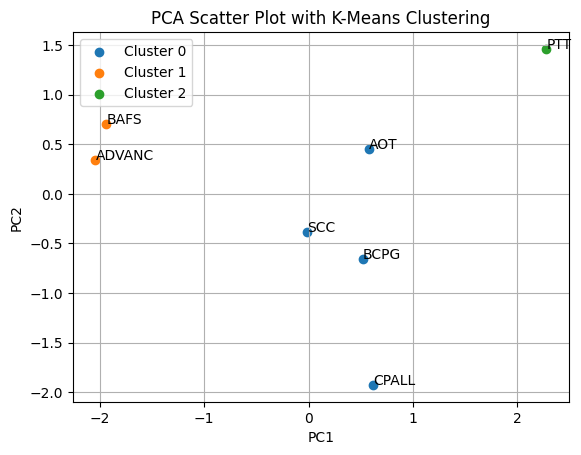

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# -------------------------
# 1) Data
# -------------------------
data = {
    'Symbol': ['PTT', 'BCPG', 'AOT', 'BAFS', 'CPALL', 'SCC', 'ADVANC'],
    'Mean_Return': [0.002, 0.001, 0.0015, 0.001, 0.0013, 0.0014, 0.0012],
    'Volatility': [0.015, 0.018, 0.012, 0.010, 0.016, 0.014, 0.011],
    'Beta': [1.05, 0.95, 1.10, 0.80, 1.20, 1.00, 0.75],
    'Sector_Correlation': [0.90, 0.87, 0.85, 0.83, 0.78, 0.81, 0.79]
}

df = pd.DataFrame(data)

# -------------------------
# 2) Feature selection
# -------------------------
X = df.drop(columns=['Symbol'])

# -------------------------
# 3) Standardize
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 4) PCA
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------------------------
# 5) K-Means
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# -------------------------
# 6) Plot (แยกสีตาม cluster)
# -------------------------
plt.figure()

for cluster_id in set(clusters):
    idx = clusters == cluster_id
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=f'Cluster {cluster_id}'
    )

# ใส่ชื่อหุ้น
for i, symbol in enumerate(df['Symbol']):
    plt.text(X_pca[i, 0], X_pca[i, 1], symbol)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Scatter Plot with K-Means Clustering')
plt.legend()
plt.grid(True)
plt.show()


#โค้ด 3.7 จัดกลุ่มคนเป็นเบาหวาน

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# -------------------------
# 1) ตัวอย่างข้อมูลผู้ป่วย
# -------------------------
data = {
    'Age': [45, 50, 38, 60, 42, 35, 55, 48, 30, 65],
    'Glucose': [180, 200, 140, 210, 170, 130, 195, 185, 120, 220],
    'BMI': [32, 35, 22, 30, 28, 21, 34, 31, 20, 33],
    'Insulin': [150, 180, 60, 200, 140, 55, 170, 160, 50, 210]
}

df = pd.DataFrame(data)

# -------------------------
# 2) Standardize ข้อมูล
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# -------------------------
# 3) K-Means Clustering
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print(df)
# ดูค่าเฉลี่ยของแต่ละกลุ่ม
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

   Age  Glucose  BMI  Insulin  Cluster
0   45      180   32      150        2
1   50      200   35      180        2
2   38      140   22       60        1
3   60      210   30      200        0
4   42      170   28      140        2
5   35      130   21       55        1
6   55      195   34      170        0
7   48      185   31      160        2
8   30      120   20       50        1
9   65      220   33      210        0
               Age     Glucose        BMI     Insulin
Cluster                                              
0        60.000000  208.333333  32.333333  193.333333
1        34.333333  130.000000  21.000000   55.000000
2        46.250000  183.750000  31.500000  157.500000


# โค้ด 3.8 การทำนายผลิตข้าวโพดด้วย Linear regression

In [ ]:
# Linear Regression: ทำนายผลผลิตข้าวโพด (กก./ไร่)
# Features: temperature, humidity, rainfall, soil_pH

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------
# 1) สร้าง/โหลดข้อมูล
# ---------------------------
# ถ้าคุณมีไฟล์ CSV ให้ใช้:
# df = pd.read_csv("corn_yield.csv")

# ตัวอย่างข้อมูลจำลอง (แทนที่ด้วยข้อมูลจริงของคุณได้เลย)
np.random.seed(42)
n = 200
temperature = np.random.normal(30, 2.5, n)          # องศา C
humidity = np.random.normal(70, 10, n)              # %
rainfall = np.random.normal(120, 40, n)             # มม./ช่วงเวลา
soil_pH = np.random.normal(6.2, 0.4, n)             # pH

# สมมติความสัมพันธ์ (เพื่อให้มี target สำหรับเดโม)
yield_kg_per_rai = (
    900
    + 20 * (temperature - 28)
    + 4 * (humidity - 65)
    + 1.2 * (rainfall - 100)
    + 80 * (soil_pH - 6.0)
    + np.random.normal(0, 80, n)  # noise
)

df = pd.DataFrame({
    "temperature": temperature,
    "humidity": humidity,
    "rainfall": rainfall,
    "soil_pH": soil_pH,
    "yield_kg_per_rai": yield_kg_per_rai
})

# ---------------------------
# 2) แยก X / y
# ---------------------------
feature_cols = ["temperature", "humidity", "rainfall", "soil_pH"]
X = df[feature_cols]
y = df["yield_kg_per_rai"]

# ---------------------------
# 3) train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# 4) Pipeline: StandardScaler + LinearRegression
# ---------------------------
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

model.fit(X_train, y_train)

# ---------------------------
# 5) ประเมินผล
# ---------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Evaluation on test set")
print(f"MAE  : {mae:.2f} kg/rai")
print(f"RMSE : {rmse:.2f} kg/rai")
print(f"R^2  : {r2:.4f}")

# ---------------------------
# 6) ดูค่าสัมประสิทธิ์ (อธิบายความสัมพันธ์เชิงเส้น)
# ---------------------------
lr = model.named_steps["lr"]
coefs = pd.Series(lr.coef_, index=feature_cols)
print("\nCoefficients")
print(coefs.sort_values(ascending=False))
print(f"\nIntercept: {lr.intercept_:.2f}")

# ---------------------------
# 7) ทดลองพยากรณ์ 1 ตัวอย่าง
# ---------------------------
sample = pd.DataFrame([{
    "temperature": 31.0,   # °C
    "humidity": 75.0,      # %
    "rainfall": 140.0,     # mm
    "soil_pH": 6.5         # pH
}])

pred_yield = model.predict(sample)[0]
print(f"\nPredicted yield: {pred_yield:.2f} kg/rai")


Evaluation on test set
MAE  : 65.61 kg/rai
RMSE : 81.30 kg/rai
R^2  : 0.4306

Coefficients
rainfall       50.272354
temperature    47.936824
soil_pH        46.602088
humidity       27.112393
dtype: float64

Intercept: 1006.34

Predicted yield: 1106.90 kg/rai


#โค้ด 3.9 จัดกลุ่มพืช

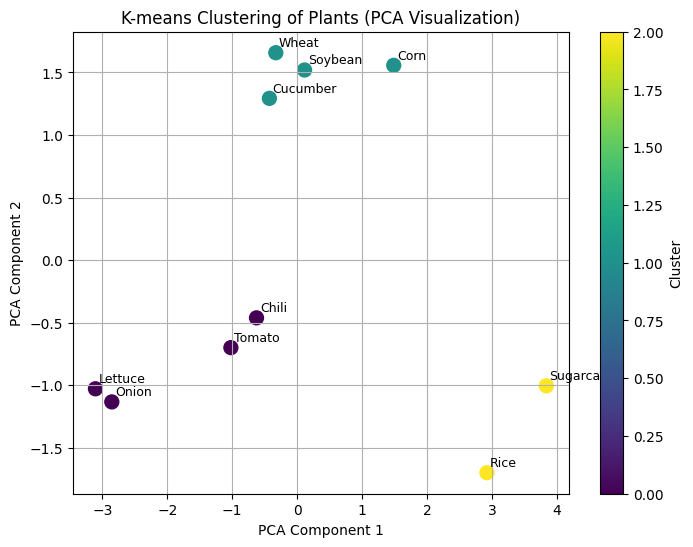

,Plant_Name,Cluster
0,Rice,2
1,Corn,1
2,Wheat,1
3,Tomato,0
4,Lettuce,0
5,Cucumber,1
6,Sugarcane,2
7,Chili,0
8,Onion,0
9,Soybean,1


In [ ]:
# ==============================
# 1) Import libraries
# ==============================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ==============================
# 2) Create dataset
# ==============================
data = {
    "Plant_ID": ["P001","P002","P003","P004","P005",
                 "P006","P007","P008","P009","P010"],
    "Plant_Name": ["Rice","Corn","Wheat","Tomato","Lettuce",
                   "Cucumber","Sugarcane","Chili","Onion","Soybean"],
    "Water_Need": [25,18,15,12,10,14,24,11,9,13],
    "Sunlight": [8,9,8,7,6,7,9,8,6,8],
    "Soil_Type": ["Clay","Loam","Loam","Sandy Loam","Sandy",
                   "Loam","Clay Loam","Sandy Loam","Sandy","Loam"],
    "Temperature": [30,28,22,26,20,25,31,27,23,26],
    "Growth_Rate": [4.5,3.8,3.0,2.5,2.2,3.0,5.0,2.4,2.1,3.2]
}

df = pd.DataFrame(data)

# ==============================
# 3) One-hot encoding (Soil_Type)
# ==============================
df_encoded = pd.get_dummies(df, columns=["Soil_Type"])

# ==============================
# 4) Select features
# ==============================
X = df_encoded.drop(columns=["Plant_ID", "Plant_Name"])

# ==============================
# 5) Standardize data
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 6) K-means clustering
# ==============================
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# ==============================
# 7) PCA for visualization
# ==============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# ==============================
# 8) Plot PCA scatter plot
# ==============================
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df["PCA1"],
    df["PCA2"],
    c=df["Cluster"],
    s=100
)

# ใส่ชื่อพืชบนจุด
for i, name in enumerate(df["Plant_Name"]):
    plt.text(df["PCA1"][i] + 0.05,
             df["PCA2"][i] + 0.05,
             name,
             fontsize=9)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clustering of Plants (PCA Visualization)")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

# ==============================
# 9) Show clustering result
# ==============================
df[["Plant_Name", "Cluster"]]


In [ ]:
pca.components_

array([[ 0.4471797 ,  0.40735767,  0.42119757,  0.45770774,  0.21650964,
         0.28429811,  0.03835481, -0.33113636, -0.0914443 ],
       [-0.1150433 ,  0.26092968, -0.14250962, -0.03596707, -0.35200919,
        -0.20814823,  0.76453146, -0.33584546, -0.18039246]])

In [5]:
# ==============================
# ดูว่า PCA1 และ PCA2 สร้างจาก feature อะไร
# ==============================

# The definition of pca_components is moved to the plotting cell (495c46a6) to ensure it's always available.
# pca_components = pd.DataFrame(
#     pca.components_,
#     columns=X.columns,
#     index=["PCA1", "PCA2"]
# )

# pca_components

#โค้ด 3.10 Random Forest Regression ทำนายกำลังการผลิตโซลาร์เซล

In [2]:
# =====================================================
# Solar Power Output Prediction using Random Forest
# =====================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# 1) สร้างข้อมูลตัวอย่าง (Simulation)
# -----------------------------
np.random.seed(42)
n = 200

data = pd.DataFrame({
    "Irradiance": np.random.uniform(200, 1000, n),     # W/m²
    "Temperature": np.random.uniform(20, 40, n),       # °C
    "Humidity": np.random.uniform(30, 90, n),          # %
    "WindSpeed": np.random.uniform(0.5, 5, n),         # m/s
    "Panel_Angle": np.random.choice([15, 20, 25, 30], n),
    "Time": np.random.choice(["Morning", "Afternoon", "Evening"], n)
})

# สมมติ PowerOutput ตามหลักฟิสิกส์โดยคร่าว
data["PowerOutput"] = (
    0.005 * data["Irradiance"]
    - 0.03 * (data["Temperature"] - 25)
    - 0.005 * data["Humidity"]
    + 0.1 * data["WindSpeed"]
    + np.where(data["Time"] == "Afternoon", 0.8, 0)
    + np.random.normal(0, 0.3, n)
)

# -----------------------------
# 2) แยกตัวแปร
# -----------------------------
X = data.drop("PowerOutput", axis=1)
y = data["PowerOutput"]

numeric_features = [
    "Irradiance", "Temperature", "Humidity",
    "WindSpeed", "Panel_Angle"
]
categorical_features = ["Time"]

# -----------------------------
# 3) Preprocessing
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

# -----------------------------
# 4) สร้าง Pipeline + Model
# -----------------------------
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

# -----------------------------
# 5) Train / Test
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# 6) Evaluation
# -----------------------------
y_pred = model.predict(X_test)

print("Model Performance")
print("R² =", round(r2_score(y_test, y_pred), 3))
print("RMSE =", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))

# -----------------------------
# 7) ทดลองทำนายค่าจริง 1 ตัวอย่าง
# -----------------------------
sample = pd.DataFrame([
    {
    "Irradiance": 850.0,
    "Temperature": 32.5,
    "Humidity": 65.0,
    "WindSpeed": 2.3,
    "Panel_Angle": 25,
    "Time": "Afternoon"
}])

prediction = model.predict(sample)
print("\nPredicted Power Output (kW):", round(prediction[0], 2))


Model Performance
R² = 0.905
RMSE = 0.403

Predicted Power Output (kW): 4.67


# โค้ด 3.11 การวิเคราะห์พฤติกรรมเครื่องจักรในโรงไฟฟ้า

Sample Power Plant Data:
   Temp_Turbine  Temp_Boiler  Pressure_Turbine  Pressure_Boiler
0    522.483571   481.502957        156.684020       139.811963
1    519.308678   482.078689        157.759276       142.865427
2    523.238443   475.919852        162.989174       137.042822
3    527.615149   481.393522        162.441481       141.512140
4    518.829233   481.758435        159.916394       138.409227

Explained Variance Ratio:
PC1: 0.420
PC2: 0.258


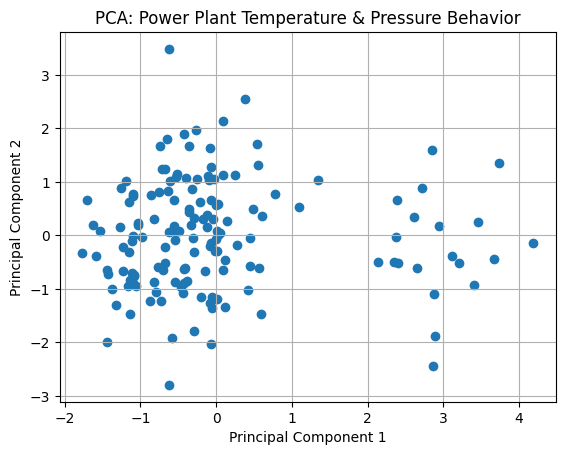


PCA Loadings:
                       PC1       PC2
Temp_Turbine     -0.150063 -0.633471
Temp_Boiler       0.695298 -0.045443
Pressure_Turbine -0.038380  0.770922
Pressure_Boiler   0.701833 -0.048268


In [3]:
# =====================================================
# PCA: Power Plant Machine Behavior Analysis
# Variables: Temperature & Pressure
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------
# 1) สร้างข้อมูลจำลอง (Power Plant Sensors)
# -----------------------------
np.random.seed(42)

time_steps = 150  # จำนวนช่วงเวลา (เช่น นาที / ชั่วโมง)

data = pd.DataFrame({
    # อุณหภูมิของเครื่องจักรในโรงไฟฟ้า (°C)
    "Temp_Turbine": np.random.normal(520, 5, time_steps),
    "Temp_Boiler": np.random.normal(480, 6, time_steps),

    # ความดันของระบบ (bar)
    "Pressure_Turbine": np.random.normal(160, 4, time_steps),
    "Pressure_Boiler": np.random.normal(140, 3, time_steps)
})

# จำลองเหตุการณ์ผิดปกติ (Boiler ร้อนและความดันสูงผิดปกติ)
data.loc[90:110, "Temp_Boiler"] += 25
data.loc[90:110, "Pressure_Boiler"] += 12

print("Sample Power Plant Data:")
print(data.head())

# -----------------------------
# 2) Standardize ข้อมูล
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# -----------------------------
# 3) PCA
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# 4) Explained Variance Ratio
# -----------------------------
print("\nExplained Variance Ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.3f}")

# -----------------------------
# 5) PCA Scatter Plot (Behavior Pattern)
# -----------------------------
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Power Plant Temperature & Pressure Behavior")
plt.grid(True)
plt.show()

# -----------------------------
# 6) PCA Loadings (Variable Contribution)
# -----------------------------
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=data.columns
)

print("\nPCA Loadings:")
print(loadings)


#โค้ด 3.12 ทำนาย PM2.5 ตามตัวแปร อุณหภูมิ ความชื้น และความเร็วลม

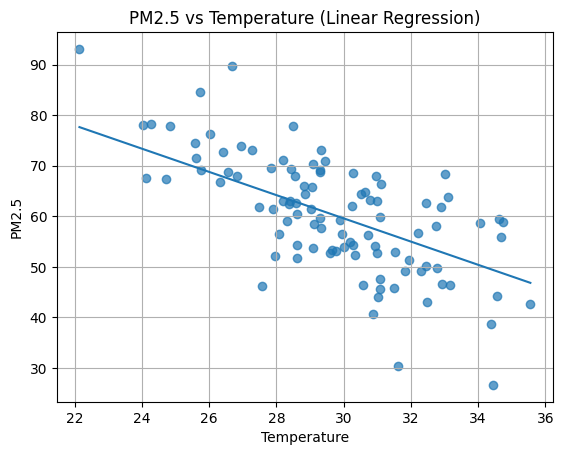

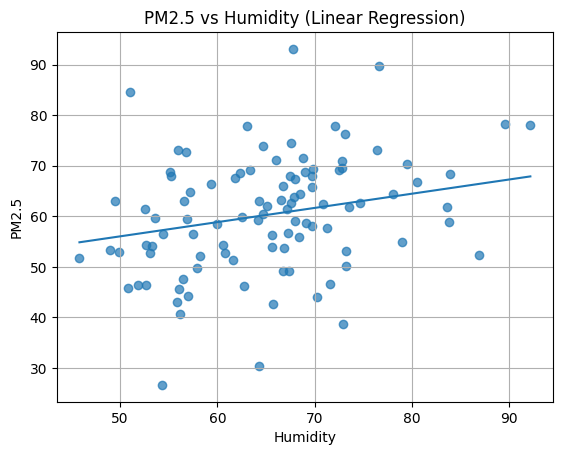

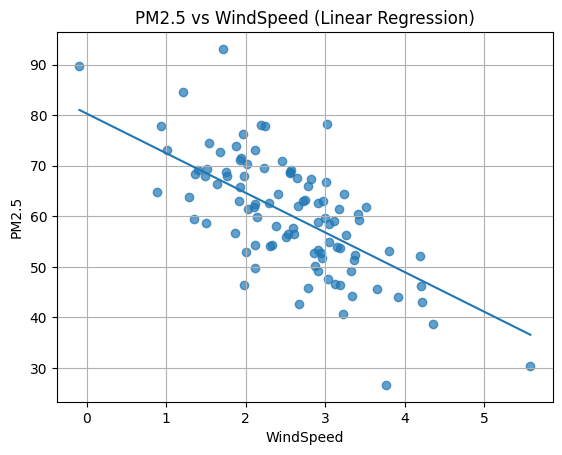

In [18]:
# =========================================
# Plot ข้อมูลจริง + Regression line
# Linear Regression: PM2.5
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# -------------------------------
# 1) สร้างข้อมูลตัวอย่าง
# -------------------------------
np.random.seed(42)
n = 100

data = pd.DataFrame({
    "Temperature": np.random.normal(30, 3, n),
    "Humidity": np.random.normal(65, 10, n),
    "WindSpeed": np.random.normal(2.5, 0.8, n)
})

data["PM25"] = (
    120
    - 2.0 * data["Temperature"]
    + 0.3 * data["Humidity"]
    - 8.0 * data["WindSpeed"]
    + np.random.normal(0, 5, n)
)

# -------------------------------
# 2) Train Linear Regression
# -------------------------------
X = data[["Temperature", "Humidity", "WindSpeed"]]
y = data["PM25"]

model = LinearRegression()
model.fit(X, y)

# -------------------------------
# 3) Plot function
# -------------------------------
def plot_regression(var):
    plt.figure()

    # scatter ข้อมูลจริง
    plt.scatter(data[var], y, alpha=0.7)

    # สร้างเส้น regression (ตรึงตัวอื่นที่ค่าเฉลี่ย)
    x_range = np.linspace(data[var].min(), data[var].max(), 100)
    X_line = pd.DataFrame({
        "Temperature": X["Temperature"].mean(),
        "Humidity": X["Humidity"].mean(),
        "WindSpeed": X["WindSpeed"].mean()
    }, index=range(100))

    X_line[var] = x_range
    y_line = model.predict(X_line)

    # เส้น regression
    plt.plot(x_range, y_line)

    plt.xlabel(var)
    plt.ylabel("PM2.5")
    plt.title(f"PM2.5 vs {var} (Linear Regression)")
    plt.grid(True)
    plt.show()

# -------------------------------
# 4) แสดงกราฟ
# -------------------------------
plot_regression("Temperature")
plot_regression("Humidity")
plot_regression("WindSpeed")


# โค้ด 3.13 จัดกลุ่มโครงสร้างเมือง

Cluster Summary:
          Latitude   Longitude  Activity
Cluster                                 
0        13.749536  100.499989  2.036766
1        13.760097  100.520127  6.030830
2        13.780298  100.479439  3.877836

Cluster → Area Type Mapping:
Cluster 0: Residential Area
Cluster 1: Commercial Area
Cluster 2: Industrial Area


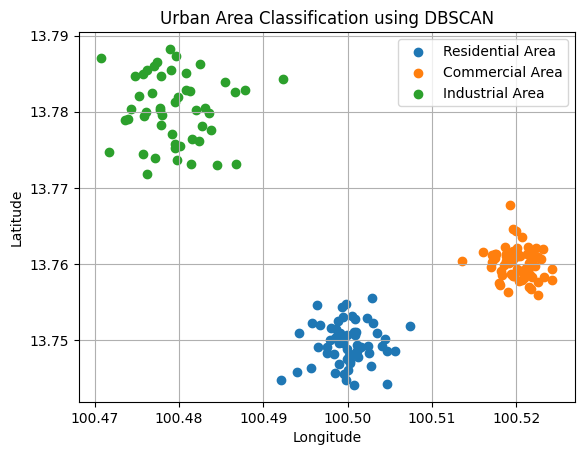

In [5]:
# =====================================================
# DBSCAN + Cluster Interpretation (Urban Area Type)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# -----------------------------
# 1) สร้างข้อมูลตัวอย่าง (GPS + Activity)
# -----------------------------
np.random.seed(42)

residential = pd.DataFrame({
    "Latitude": np.random.normal(13.75, 0.003, 60),
    "Longitude": np.random.normal(100.50, 0.003, 60),
    "Activity": np.random.normal(2, 0.4, 60)
})

commercial = pd.DataFrame({
    "Latitude": np.random.normal(13.76, 0.002, 70),
    "Longitude": np.random.normal(100.52, 0.002, 70),
    "Activity": np.random.normal(6, 0.6, 70)
})

industrial = pd.DataFrame({
    "Latitude": np.random.normal(13.78, 0.004, 50),
    "Longitude": np.random.normal(100.48, 0.004, 50),
    "Activity": np.random.normal(4, 0.5, 50)
})

data = pd.concat(
    [residential, commercial, industrial],
    ignore_index=True
)

# -----------------------------
# 2) Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# -----------------------------
# 3) DBSCAN
# -----------------------------
dbscan = DBSCAN(eps=0.8, min_samples=10)
data["Cluster"] = dbscan.fit_predict(X_scaled)

# -----------------------------
# 4) วิเคราะห์ค่าเฉลี่ยของแต่ละ Cluster
# -----------------------------
summary = data.groupby("Cluster").mean()
print("Cluster Summary:")
print(summary)

# -----------------------------
# 5) ตั้งชื่อ Cluster อัตโนมัติจาก Activity
# -----------------------------
cluster_label = {}

for cluster_id, row in summary.iterrows():
    if cluster_id == -1:
        cluster_label[cluster_id] = "Noise / Other"
    elif row["Activity"] < 3:
        cluster_label[cluster_id] = "Residential Area"
    elif row["Activity"] < 5:
        cluster_label[cluster_id] = "Industrial Area"
    else:
        cluster_label[cluster_id] = "Commercial Area"

data["Area_Type"] = data["Cluster"].map(cluster_label)

print("\nCluster → Area Type Mapping:")
for k, v in cluster_label.items():
    print(f"Cluster {k}: {v}")

# -----------------------------
# 6) Visualization พร้อมชื่อพื้นที่
# -----------------------------
plt.figure()

for area in data["Area_Type"].unique():
    subset = data[data["Area_Type"] == area]
    plt.scatter(
        subset["Longitude"],
        subset["Latitude"],
        label=area
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Urban Area Classification using DBSCAN")
plt.legend()
plt.grid(True)
plt.show()
